# Microscopic Imagery Misaligment Classifier
## Contributions: Jerome MASSOT [add your name here]
### Latest Update: 2026-04-21

The objective of this notebook is to see if we can fine-tune an EfficientNet architecture to detect if microscopic images are misaligned.

- The base model is a EfficientNetBx model that has been pre-trained on the ImageNet dataset.
- The model is then fine-tuned on the public dataset provided by the Allen Institute.

## 00- Setup and Modules Imports

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [2]:
import quilt3 as q3

In [3]:
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import sklearn
import keras

from collections import defaultdict
from pathlib import Path
import random
import tqdm
import math
import os
import re

In [4]:
# check if the cuda is available
import jax

try:
    # 1. Check the default backend (should be 'gpu')
    print(f"JAX Backend: {jax.default_backend()}")

    # 2. List all available devices
    devices = jax.devices()
    print(f"Available Devices: {devices}")

    # 3. Explicitly count GPUs
    gpu_count = jax.device_count(backend='gpu')
    print(f"Number of GPUs: {gpu_count}")

except RuntimeError as e:
    print("JAX could not find a GPU backend. It fell back to CPU.")
    print(f"Error details: {e}")

JAX Backend: gpu
Available Devices: [CudaDevice(id=0)]
Number of GPUs: 1


E0424 16:07:24.838946   89750 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0424 16:07:24.865216   89613 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


## 01- Data loading, pre-processing, and Datasets creation

In [ ]:
b = q3.Bucket("s3://aind-scratch-data")
b.fetch("stitch_doctor/microscopy/", "../data/microscopy/")

### 01-01- Image Resizing and Tiling

The following code allows to tile the original images.

In [ ]:
TILE_SIZE_PER_MODEL = {
    "EfficientNet-B0": 224,
    "EfficientNet-B1": 240,
    "EfficientNet-B2": 260,
    "EfficientNet-B3": 300,
    "EfficientNet-B4": 380,
    "EfficientNet-B5": 456,
    "EfficientNet-B6": 528,
    "EfficientNet-B7": 600
}

In [ ]:
def compute_stride(image_dim: int, tile_size: int, overlap: int) -> tuple[int, int]:
    """
    Return (stride, num_tiles) for one dimension.
 
    stride   = tile_size - overlap
    The last tile is shifted left/up so it fits inside the image
    (instead of being padded), which avoids black borders.
    """
    stride = tile_size - overlap
    if stride <= 0:
        raise ValueError(f"Overlap ({overlap}) must be less than tile size ({tile_size}).")
 
    if image_dim <= tile_size:
        return stride, 1
 
    # How many full strides fit after the first tile?
    num_tiles = math.ceil((image_dim - tile_size) / stride) + 1
    return stride, num_tiles
 
 
def _resize_if_smaller(img: Image.Image, tile_size: int) -> tuple[Image.Image, bool]:
    """
    If either dimension of *img* is smaller than *tile_size*, scale the image
    up proportionally so that the shorter side equals *tile_size*.
    The aspect ratio is preserved with high-quality (Lanczos) resampling.
 
    Returns (possibly_resized_image, was_resized).
    """
    w, h = img.size
    if w >= tile_size and h >= tile_size:
        return img, False
 
    # Scale factor needed to bring the smallest dimension up to tile_size.
    scale = tile_size / min(w, h)
    new_w = math.ceil(w * scale)
    new_h = math.ceil(h * scale)
    return img.resize((new_w, new_h), Image.LANCZOS), True
 
 
def generate_tiles(
    image_path: str | Path,
    output_dir: str | Path,
    tile_size: int = 300,
    overlap: int = 0,
    strict: bool = False,
    verbose: bool = False
) -> list[Path]:
    """
    Slice *image_path* into TILE_SIZE×TILE_SIZE tiles.
 
    If either dimension of the source image is smaller than TILE_SIZE the image
    is proportionally upscaled so its shortest side equals TILE_SIZE, and the
    resulting image is treated as a single tile.
 
    Parameters
    ----------
    image_path  : path to the source image
    tile_size   : tile size in pixel
    overlap     : pixel overlap between adjacent tiles (0 = no overlap)
    output_dir  : folder for saved tiles; defaults to <image_stem>_tiles/
    strict      : if True, skip the edge-adjusted last tile when the image
                  is not an exact multiple of the stride (keeps all tiles
                  at the same grid position, but the rightmost/bottom column
                  may be missing)
    verbose     : if True, print information about the tiling process
 
    Returns
    -------
    List of Paths to the saved tile images.
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")
 
    img = Image.open(image_path)
    img_w, img_h = img.size

    if verbose:
        print(f"Source image : {image_path.name}  ({img_w} × {img_h} px)")
 
    # ── resize if either dimension is smaller than the tile size ─────────────
    img, was_resized = _resize_if_smaller(img, tile_size)
    if was_resized:
        img_w, img_h = img.size

        if verbose:
            print(f"Resized to   : {img_w} × {img_h} px  "
                  f"(shortest side < {tile_size} px — upscaled proportionally)")
 
    # ── output directory ──────────────────────────────────────────────────────
    output_dir = Path(output_dir).resolve()
 
    # <output_dir> / <mirrored parent dirs> / <image stem> /
    folders = image_path.parts

    tile_dir = output_dir / Path(*folders[2:-1])  / image_path.stem
    tile_dir.mkdir(parents=True, exist_ok=True)
 
    # ── stride + tile counts ──────────────────────────────────────────────────
    stride_x, n_cols = compute_stride(img_w, tile_size, overlap)
    stride_y, n_rows = compute_stride(img_h, tile_size, overlap)

    if verbose:
        print(f"Stride       : {stride_x} px (x)  {stride_y} px (y)")
        print(f"Grid         : {n_cols} cols × {n_rows} rows = {n_cols * n_rows} tiles")
        print(f"Output dir   : {output_dir}\n")
 
    saved: list[Path] = []
    ext = image_path.suffix.lower() or ".png"
    # JPEG does not support transparency; fall back to PNG when needed.
    save_format = "JPEG" if ext in (".jpg", ".jpeg") else "PNG"
    save_ext    = ext if ext in (".jpg", ".jpeg") else ".png"
 
    for row in range(n_rows):
        for col in range(n_cols):
            # nominal top-left corner
            x = col * stride_x
            y = row * stride_y
 
            # clamp so the tile never exceeds the image boundary
            x = min(x, max(0, img_w - tile_size))
            y = min(y, max(0, img_h - tile_size))
 
            if strict and (x + tile_size > img_w or y + tile_size > img_h):
                # in strict mode drop tiles that would require clamping
                continue
 
            box = (x, y, x + tile_size, y + tile_size)
            tile = img.crop(box)
 
            tile_name = f"{image_path.stem}_r{row:03d}_c{col:03d}{save_ext}"
            tile_path = tile_dir / tile_name
            tile.save(tile_path, format=save_format)
            saved.append(tile_path)
    if verbose:
        print(f"Saved {len(saved)} tile(s) to '{output_dir}'.")
    return saved

In [ ]:
folder = Path("../data")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
image_paths = [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]

for image_path in tqdm.tqdm(image_paths):
    generate_tiles(
        image_path=image_path,
        tile_size=TILE_SIZE_PER_MODEL["EfficientNet-B3"],
        overlap=10,
        output_dir="../tiles/",
        strict=True
    )

### 01-02- Datasets creation

#### 01-02-01- Naive Approach

The following code block performs the **Initial Data Partitioning**. 

It takes the raw dataset and splits it into three distinct subsets required for a standard machine learning workflow: Training, Validation, and Testing.

Here is a breakdown of the key components for your users:

**1. Reproducibility with random.seed(42)**

The number 42 is arbitrary, but setting a "seed" is critical. It ensures that the "random" split is the same every time someone runs this notebook. Without this, you would get different training and test sets every time, making it impossible to compare results or debug performance issues accurately.

**2. The Data Structure (defaultdict)**

We use defaultdict(list) to hold our split data. This is a special dictionary that automatically creates an empty list the first time we reference a new key (like 'train'). It prevents "KeyError" crashes and keeps the code clean while we append molecule data to each category.

**3. The splitting logic (70/10/20)**

Rather than using a library like Scikit-Learn (which often requires loading everything into memory at once), this logic iterates through the dataset and assigns each row to a category based on a random number between 0 and 1:

- Train (70%): Assigned if the number is < 0.8. This data is used to teach the model.
- Validation (10%): Assigned if the number is between 0.8 and 0.9. This acts as a "practice exam" to help us tune model settings (hyperparameters) without looking at the final test.
- Test (20%): Assigned if the number is > 0.9. This is the "final exam"—it is never seen by the model during training and is used for the final, unbiased evaluation of its accuracy.

**4. Payload Extraction**
The code extracts:

- image_path: The path of the image.
- label: good or bad alignment based on the original image folder.

In [13]:
# Using a Pandas DataFrame for easier partitioning
random.seed(42)

# using the tiles
folder = Path("../tiles")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
image_paths = [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]

image_data = []
for image_path in image_paths:

    random_number = random.uniform(0, 1)
    if random_number < 0.7:
        category = 'train'
    elif random_number < 0.9:
        category = 'test'
    else:
        category = 'validation'

    path_str = str(image_path)
    image_data.append({
        "path": path_str,
        "magenta": "Y" if "magenta" in path_str else "N",
        "misaligned": 1 if "bad" in path_str else 0,
        "category": category
    })

image_data_df = pd.DataFrame.from_dict(image_data)

In [14]:
pd.set_option("display.max_colwidth", 200)
image_data_df.head()

,path,magenta,misaligned,category
0,../tiles/microscopy/SPIM/smartSPIM/good/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-556730_772600.ome.zarr-smartSPIM_00_left10/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-5...,N,0,train
1,../tiles/microscopy/SPIM/smartSPIM/good/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-556730_772600.ome.zarr-smartSPIM_00_left10/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-5...,N,0,train
2,../tiles/microscopy/SPIM/smartSPIM/good/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-556730_772600.ome.zarr-smartSPIM_00_left10/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-5...,N,0,train
3,../tiles/microscopy/SPIM/smartSPIM/good/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-556730_772600.ome.zarr-smartSPIM_00_left10/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-5...,N,0,train
4,../tiles/microscopy/SPIM/smartSPIM/good/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-556730_772600.ome.zarr-smartSPIM_00_left10/SmartSPIM_792085_2025-04-08_22-14-37-SPIM-Ex_488_Em_525-5...,N,0,test


In [15]:
image_data_df.tail()

,path,magenta,misaligned,category
4533,../tiles/microscopy/SPIM/exaSPIM/bad/magenta/exaSPIM_701771_tile_000007_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328/exaSPIM_701771_tile_000007_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328_r000_c001...,Y,1,validation
4534,../tiles/microscopy/SPIM/exaSPIM/bad/magenta/exaSPIM_701771_tile_000007_ch_488.zarr-exaSPIM_00_z00000_y02048_x02560/exaSPIM_701771_tile_000007_ch_488.zarr-exaSPIM_00_z00000_y02048_x02560_r000_c000...,Y,1,train
4535,../tiles/microscopy/SPIM/exaSPIM/bad/magenta/exaSPIM_701771_tile_000011_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328/exaSPIM_701771_tile_000011_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328_r000_c001...,Y,1,train
4536,../tiles/microscopy/SPIM/exaSPIM/bad/magenta/exaSPIM_701771_tile_000011_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328/exaSPIM_701771_tile_000011_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328_r000_c000...,Y,1,test
4537,../tiles/microscopy/SPIM/exaSPIM/bad/magenta/exaSPIM_701771_tile_000011_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328/exaSPIM_701771_tile_000011_ch_488.zarr-exaSPIM_00_z04352_y02560_x03328_r000_c002...,Y,1,train


Let's check the number of images per dataset category. The dataset seems balanced for all possible data combination.

In [16]:
image_data_df.groupby(["category", "misaligned"])["misaligned"].count()

category    misaligned
test        0              417
            1              490
train       0             1450
            1             1741
validation  0              208
            1              232
Name: misaligned, dtype: int64

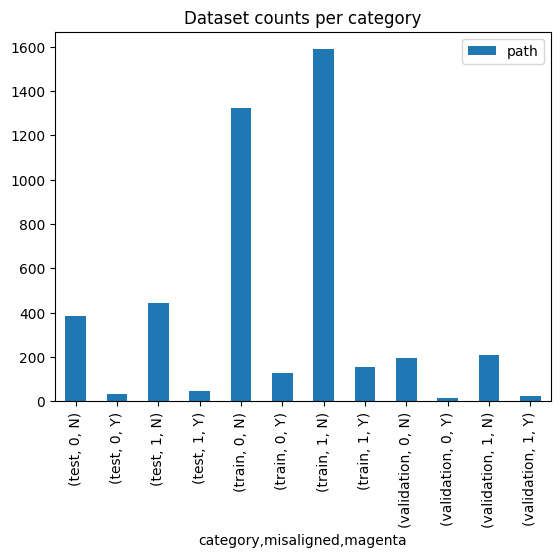

In [17]:
image_data_df.groupby(["category", "misaligned", "magenta"]).count().plot(kind="bar", title="Dataset counts per category");

In [ ]:
# export the datasets as csv files
image_data_df[image_data_df["category"]=="train"][["path", "magenta", "misaligned"]].to_csv("../datasets/train.csv", index=False)
image_data_df[image_data_df["category"]=="test"][["path", "magenta", "misaligned"]].to_csv("../datasets/test.csv", index=False)
image_data_df[image_data_df["category"]=="validation"][["path", "magenta", "misaligned"]].to_csv("../datasets/validation.csv", index=False)
image_data_df.to_csv("../datasets/full.csv", index=False)

#### 01-02-02- Right approach

The main issue with the naive approach is that it assumes that each image in the original dataset is not duplicated. However, it has been proven that a significant number of images are softly replicated several times in the original dataset. By softly replicated, one means that two images are extremely similar, even if not perfectly identical from a pixel perspective. When this scenario happens, the dataset creation has to been done with extreme caution to avoid data leakage, in particular between the test and the (train, validation) datasets.

##### exaSPIM images

In [5]:
# exaSPIM images

exaSPIM_image_data = []
folder = Path("../tiles/microscopy/SPIM/exaSPIM")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
image_paths = [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
print(f"There are {len(image_paths)} images in this collection...")

# here the split between the dataset categories is based on the original image names
original_images_per_origin = defaultdict(list)
for image_path in image_paths:
    path_str = str(image_path)
    match = re.search(r"tile_\d+", path_str)
    if match:
        original_images_per_origin[match.group()].append(path_str)

print(f"There are {len(original_images_per_origin.keys())} different origins in this collection...")

# let's see how many tiles per origin
for origin, images in original_images_per_origin.items():
    print(f"There are {len(images)} different images in the {origin} collection...")

# let's consider that the train dataset is made of tile_000006
for path_str in original_images_per_origin['tile_000006']:
    exaSPIM_image_data.append({
        "path": path_str,
        "magenta": "Y" if "magenta" in path_str else "N",
        "misaligned": 1 if "bad" in path_str else 0,
        "category": 'train'
    })

# let's consider that the validation dataset is made of tile_000008
for path_str in original_images_per_origin['tile_000008']:
    exaSPIM_image_data.append({
        "path": path_str,
        "magenta": "Y" if "magenta" in path_str else "N",
        "misaligned": 1 if "bad" in path_str else 0,
        "category": 'validation'
    })

# let's consider that the test dataset is made of the remaining tiles
for path_str in original_images_per_origin['tile_000007']:
    exaSPIM_image_data.append({
        "path": path_str,
        "magenta": "Y" if "magenta" in path_str else "N",
        "misaligned": 1 if "bad" in path_str else 0,
        "category": 'test'
    })
for path_str in original_images_per_origin['tile_000011']:
    exaSPIM_image_data.append({
        "path": path_str,
        "magenta": "Y" if "magenta" in path_str else "N",
        "misaligned": 1 if "bad" in path_str else 0,
        "category": 'test'
    })

print(f"There are {len(exaSPIM_image_data)} images in these datasets...")

# final check if we have not lost image in the process
assert(len(image_paths) == (len(exaSPIM_image_data)))

There are 2463 images in this collection...
There are 4 different origins in this collection...
There are 88 different images in the tile_000007 collection...
There are 1925 different images in the tile_000006 collection...
There are 240 different images in the tile_000008 collection...
There are 210 different images in the tile_000011 collection...
There are 2463 images in these datasets...


##### smartSPIM images

In [6]:
# smartSPIM images

smartSPIM_image_data = []
folder = Path("../tiles/microscopy/SPIM/smartSPIM")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
image_paths = [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
print(f"There are {len(image_paths)} images in this collection...")

# here the split between the dataset categories is based on the original image names
original_images_per_origin = defaultdict(list)
for image_path in image_paths:
    path_str = str(image_path)
    match = re.search(r"Ex_\d+-\d+_\d+", path_str)
    if match:
        original_images_per_origin[match.group()].append(path_str)
    else:
        match = re.search(r"Ex_\d+_Em_\d+-\d+_\d+", path_str)
        if match:
            original_images_per_origin[match.group()].append(path_str)

print(f"There are {len(original_images_per_origin.keys())} different origins in this collection...")

# let's see how many tiles per origin
for origin, images in original_images_per_origin.items():
    print(f"There are {len(images)} different images in the {origin} collection...")

# let's consider that the train dataset is made of 
for collection_name in [
    "Ex_488_Em_525-556730_772600", 
    "Ex_488_Em_525-524330_772600", 
    "Ex_639_Em_680-565780_477820",
    "Ex_639_Em_680-533380_477820",
    "Ex_639_Em_680-491930_746680", 
    "Ex_488_Em_525-491930_746680",
    "Ex_639_Em_680-565780_503740",
    "Ex_639_Em_680-533380_425980"
]: 
    for path_str in original_images_per_origin[collection_name]:
        smartSPIM_image_data.append({
            "path": path_str,
            "magenta": "Y" if "magenta" in path_str else "N",
            "misaligned": 1 if "bad" in path_str else 0,
            "category": 'train'
        })

# let's consider that the test dataset is made of 
for collection_name in [
    "Ex_639_Em_680-556730_798520",
    "Ex_639_Em_680-533380_503740",
    "Ex_639-533380_503740"
]: 
    for path_str in original_images_per_origin[collection_name]:
        smartSPIM_image_data.append({
            "path": path_str,
            "magenta": "Y" if "magenta" in path_str else "N",
            "misaligned": 1 if "bad" in path_str else 0,
            "category": 'test'
        })

# let's consider that the validation dataset is made of 
for collection_name in [
    "Ex_639-533380_477820"
]: 
    for path_str in original_images_per_origin[collection_name]:
        smartSPIM_image_data.append({
            "path": path_str,
            "magenta": "Y" if "magenta" in path_str else "N",
            "misaligned": 1 if "bad" in path_str else 0,
            "category": 'validation'
        })

print(f"There are {len(smartSPIM_image_data)} images in these datasets...")

# final check if we have not lost image in the process
assert(len(image_paths) == (len(smartSPIM_image_data)))

There are 900 images in this collection...
There are 12 different origins in this collection...
There are 90 different images in the Ex_488_Em_525-556730_772600 collection...
There are 90 different images in the Ex_488_Em_525-524330_772600 collection...
There are 90 different images in the Ex_639_Em_680-565780_477820 collection...
There are 32 different images in the Ex_639_Em_680-533380_477820 collection...
There are 90 different images in the Ex_639_Em_680-533380_425980 collection...
There are 90 different images in the Ex_488_Em_525-491930_746680 collection...
There are 90 different images in the Ex_639_Em_680-565780_503740 collection...
There are 32 different images in the Ex_639_Em_680-533380_503740 collection...
There are 90 different images in the Ex_639_Em_680-491930_746680 collection...
There are 90 different images in the Ex_639_Em_680-556730_798520 collection...
There are 58 different images in the Ex_639-533380_503740 collection...
There are 58 different images in the Ex_63

##### Z1 images

In [7]:
# Z1 images

Z1_image_data = []
folder = Path("../tiles/microscopy/SPIM/Z1")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
image_paths = [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
print(f"There are {len(image_paths)} images in this collection...")

# here the split between the dataset categories is based on the original image names
original_images_per_origin = defaultdict(list)
for image_path in image_paths:
    path_str = str(image_path)
    match = re.search(r"s\d+(?=[-_])", path_str)
    if match:
        original_images_per_origin[match.group()].append(path_str)
    else:
        match = re.search(r"affine_\d+", path_str)
        if match:
            original_images_per_origin[match.group()].append(path_str)

print(f"There are {len(original_images_per_origin.keys())} different origins in this collection...")

# let's see how many tiles per origin
for origin, images in original_images_per_origin.items():
    print(f"There are {len(images)} different images in the {origin} collection...")

# let's consider that the train dataset is made of 
for collection_name in [
    "affine_00", 
    "affine_01", 
    "affine_02",
    "affine_03",
    "affine_04", 
    "s40",
    "s41",
    "s42"
]: 
    for path_str in original_images_per_origin[collection_name]:
        Z1_image_data.append({
            "path": path_str,
            "magenta": "Y" if "magenta" in path_str else "N",
            "misaligned": 1 if "bad" in path_str else 0,
            "category": 'train'
        })

for collection_name in [
    "affine_05",
    "affine_06", 
    "affine_07", 
    "s107",
    "s43",
    "s49"
]: 
    for path_str in original_images_per_origin[collection_name]:
        Z1_image_data.append({
            "path": path_str,
            "magenta": "Y" if "magenta" in path_str else "N",
            "misaligned": 1 if "bad" in path_str else 0,
            "category": 'test'
        })

for collection_name in [
    "affine_08",
    "s50"
]: 
    for path_str in original_images_per_origin[collection_name]:
        Z1_image_data.append({
            "path": path_str,
            "magenta": "Y" if "magenta" in path_str else "N",
            "misaligned": 1 if "bad" in path_str else 0,
            "category": 'validation'
        })


print(f"There are {len(Z1_image_data)} images in these datasets...")

# final check if we have not lost image in the process
assert(len(image_paths) == (len(Z1_image_data)))

There are 1175 images in this collection...
There are 15 different origins in this collection...
There are 66 different images in the affine_01 collection...
There are 321 different images in the s107 collection...
There are 99 different images in the s50 collection...
There are 77 different images in the s49 collection...
There are 88 different images in the s41 collection...
There are 99 different images in the s43 collection...
There are 183 different images in the s40 collection...
There are 77 different images in the s42 collection...
There are 44 different images in the affine_03 collection...
There are 22 different images in the affine_05 collection...
There are 22 different images in the affine_06 collection...
There are 22 different images in the affine_02 collection...
There are 11 different images in the affine_08 collection...
There are 22 different images in the affine_00 collection...
There are 22 different images in the affine_04 collection...
There are 1175 images in th

##### Merging Data Collections

In [8]:
merged_image_data = []
for image_data_collection in [exaSPIM_image_data, smartSPIM_image_data, Z1_image_data]:
    merged_image_data.extend(image_data_collection)


consistent_image_data_df = pd.DataFrame.from_dict(merged_image_data)

In [9]:
pd.set_option("display.max_colwidth", 200)
consistent_image_data_df.head()

,path,magenta,misaligned,category
0,../tiles/microscopy/SPIM/exaSPIM/good/exaSPIM_720164_2025-07-07_17-55-45_processed_2025-07-15_16-22-02-flatfield_correction-SPIM.ome.zarr-tile_000006_ch_488.zarr-exaSPIM_04_left10_third2/exaSPIM_7...,N,0,train
1,../tiles/microscopy/SPIM/exaSPIM/good/exaSPIM_720164_2025-07-07_17-55-45_processed_2025-07-15_16-22-02-flatfield_correction-SPIM.ome.zarr-tile_000006_ch_488.zarr-exaSPIM_04_left10_third2/exaSPIM_7...,N,0,train
2,../tiles/microscopy/SPIM/exaSPIM/good/exaSPIM_720164_2025-07-07_17-55-45_processed_2025-07-15_16-22-02-flatfield_correction-SPIM.ome.zarr-tile_000006_ch_488.zarr-exaSPIM_04_left10_third2/exaSPIM_7...,N,0,train
3,../tiles/microscopy/SPIM/exaSPIM/good/exaSPIM_720164_2025-07-07_17-55-45_processed_2025-07-15_16-22-02-flatfield_correction-SPIM.ome.zarr-tile_000006_ch_488.zarr-exaSPIM_04_left10_third2/exaSPIM_7...,N,0,train
4,../tiles/microscopy/SPIM/exaSPIM/good/exaSPIM_720164_2025-07-07_17-55-45_processed_2025-07-15_16-22-02-flatfield_correction-SPIM.ome.zarr-tile_000006_ch_488.zarr-exaSPIM_04_left10_third2/exaSPIM_7...,N,0,train


In [10]:
consistent_image_data_df.tail()

,path,magenta,misaligned,category
4533,../tiles/microscopy/SPIM/Z1/bad/000000_s50-hcr_affine_00_left10/000000_s50-hcr_affine_00_left10_r000_c000.png,N,1,validation
4534,../tiles/microscopy/SPIM/Z1/bad/000000_s50-hcr_affine_00_left10/000000_s50-hcr_affine_00_left10_r005_c000.png,N,1,validation
4535,../tiles/microscopy/SPIM/Z1/bad/000000_s50-hcr_affine_00_left10/000000_s50-hcr_affine_00_left10_r010_c000.png,N,1,validation
4536,../tiles/microscopy/SPIM/Z1/bad/000000_s50-hcr_affine_00_left10/000000_s50-hcr_affine_00_left10_r009_c000.png,N,1,validation
4537,../tiles/microscopy/SPIM/Z1/bad/000000_s50-hcr_affine_00_left10/000000_s50-hcr_affine_00_left10_r006_c000.png,N,1,validation


In [11]:
consistent_image_data_df.groupby(["category", "misaligned"])["misaligned"].count()

category    misaligned
test        0              421
            1              598
train       0             1462
            1             1649
validation  0              192
            1              216
Name: misaligned, dtype: int64

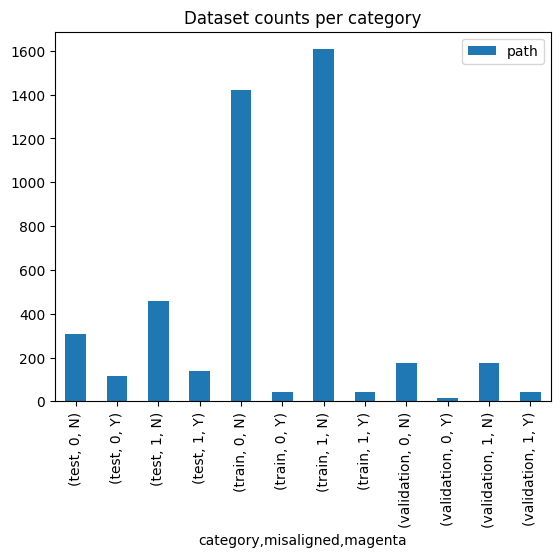

In [12]:
consistent_image_data_df.groupby(["category", "misaligned", "magenta"]).count().plot(kind="bar", title="Dataset counts per category");

In [20]:
# export the datasets as csv files
consistent_image_data_df[consistent_image_data_df["category"]=="train"][["path", "magenta", "misaligned"]].to_csv("../datasets/consistent_train.csv", index=False)
consistent_image_data_df[consistent_image_data_df["category"]=="test"][["path", "magenta", "misaligned"]].to_csv("../datasets/consistent_test.csv", index=False)
consistent_image_data_df[consistent_image_data_df["category"]=="validation"][["path", "magenta", "misaligned"]].to_csv("../datasets/consistent_validation.csv", index=False)
consistent_image_data_df.to_csv("../datasets/consistent_full.csv", index=False)

## 02- Datasets creation

In [21]:
class ImageDataPipeline(keras.utils.PyDataset):

    def __init__(self, file_paths, labels, batch_size=32, img_size=(300, 300), shuffle=True, seed=42, **kwargs):
        super().__init__(**kwargs)
        self.file_paths = np.array(file_paths)
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.seed = seed
        if self.shuffle: self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        index = index % len(self)
        start_index = index * self.batch_size
        end_index = min((index + 1) * self.batch_size, len(self.file_paths))
        batch_paths = self.file_paths[start_index:end_index]
        batch_labels = self.labels[start_index:end_index]
        
        X = self._load_batch_images(batch_paths)
        return X, batch_labels.reshape(-1, 1).astype("float32")

    def _load_batch_images(self, batch_paths):
        images = []
        for path in batch_paths:
            img = Image.open(path)
            img = img.resize(self.img_size)
            images.append(np.array(img))
        return np.array(images).astype('float32')

    def on_epoch_end(self):
        if self.shuffle:
            np.random.seed(self.seed)
            indices = np.arange(len(self.file_paths))
            np.random.shuffle(indices)
            self.file_paths = self.file_paths[indices]
            self.labels = self.labels[indices]


Now we can create the dataset used for fine-tuning the model.

In [22]:
# Define common settings once
common = {"batch_size": 16, "img_size": (300, 300)}

# let extract the image paths and labels from the Pandas DataFrame
X_train = consistent_image_data_df[consistent_image_data_df["category"]=="train"]["path"]
y_train = consistent_image_data_df[consistent_image_data_df["category"]=="train"]["misaligned"]

X_val = consistent_image_data_df[consistent_image_data_df["category"]=="validation"]["path"]
y_val = consistent_image_data_df[consistent_image_data_df["category"]=="validation"]["misaligned"]

X_test = consistent_image_data_df[consistent_image_data_df["category"]=="test"]["path"]
y_test = consistent_image_data_df[consistent_image_data_df["category"]=="test"]["misaligned"]


# Create datasets concisely
train_ds = ImageDataPipeline(X_train, y_train, shuffle=True, workers=4, use_multiprocessing=True, **common)
val_ds   = ImageDataPipeline(X_val, y_val, shuffle=False, **common)
test_ds  = ImageDataPipeline(X_test, y_test, shuffle=False, **common)

In [23]:
# test the dimensions of the datasets
X_batch, y_batch = train_ds[0]
print(f"Images Batch Shape: {X_batch.shape}")
print(f"Labels Batch Shape: {y_batch.shape}")

Images Batch Shape: (16, 300, 300, 3)
Labels Batch Shape: (16, 1)


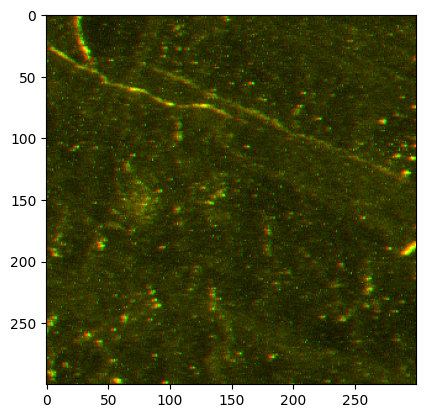

In [24]:
plt.imshow(X_batch[0,:,:,:]/255.0);

In [25]:
# test the dimensions of the datasets
X_batch, y_batch = val_ds[0]
print(f"Images Batch Shape: {X_batch.shape}")
print(f"Labels Batch Shape: {y_batch.shape}")

Images Batch Shape: (16, 300, 300, 3)
Labels Batch Shape: (16, 1)


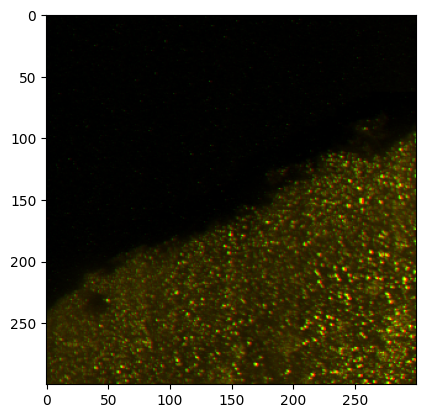

In [26]:
plt.imshow(X_batch[0,:,:,:]/255.0);

## 03- Model Retrieval and Two-Step Fine-Tuning

In [27]:
from keras.applications import EfficientNetB3
from keras import layers

IMG_SIZE = 300

def build_binary_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model = EfficientNetB3(include_top=False, input_tensor=inputs, weights="imagenet")
    
    base_model.trainable = False
    x = layers.GlobalAveragePooling2D(name="avg_pool")(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5, name="top_dropout")(x)
    
    # Binary output (Sigmoid)
    outputs = layers.Dense(1, activation="sigmoid", name="pred")(x)
    model = keras.Model(inputs, outputs, name="EfficientNet_Binary")
    
    # Lower learning rate for stable initialization
    optimizer = keras.optimizers.Adam(learning_rate=2e-4)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [28]:
model = build_binary_model()

When you run a complex model (like EfficientNetB3 in your notebook), XLA tries to "autotune" the operations. It runs several versions of the same mathematical operation (e.g., a convolution) to see which implementation is fastest on your specific hardware.

To measure these times accurately, it uses a "delay kernel"— a tiny probe sent to the GPU to calibrate for launch latency and noise. 

An error `Delay kernel timed out` can pop-up, meaning the GPU didn't respond to this probe within the expected time.

Common reasons for the timeout:
- Cold Start: The GPU was initializing or busy with the first-ever JIT compilation of the model.
- Load Spikes: High system load during the very first batch.
- Accuracy: Because it timed out, XLA might have chosen a "good" implementation instead of the absolute "best" one, hence "sub-optimal accuracy."

In a single GPU environment, this is rarely fatal and usually safe to ignore if it only happens once. However, you can mitigate it by refining your warmup strategy.

In [30]:
print("Warming up GPU...")

# Create a small dummy batch matching your input shape
dummy_input = np.random.uniform(size=(1, 300, 300, 3)).astype("float32")

print("Warming up model and XLA autotuner...")
# Run a single train step (or just a call) and block until it's finished
# This triggers compilation and autotuning for the real workload
_ = model(dummy_input)

print("Model warmed up.")

Warming up GPU...
Warming up model and XLA autotuner...
Model warmed up.


Let's train the binary head.

In [ ]:
binary_model_training_history = model.fit(
    train_ds, 
    epochs=40, 
    validation_data=val_ds
)

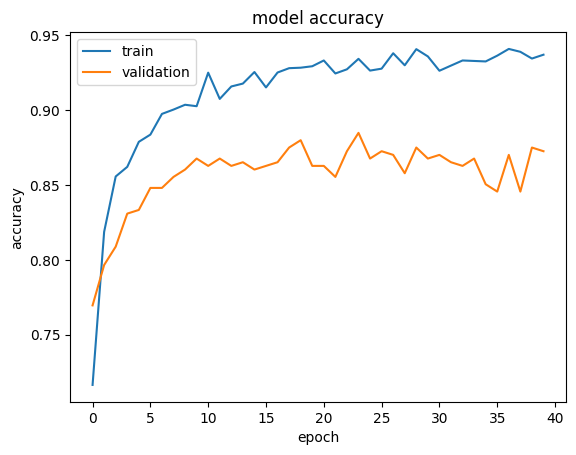

In [32]:
def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()

plot_hist(binary_model_training_history)

In [33]:
# Save the entire model
model.save("../models/consistent_image_misalignment_binary_model_enb3.keras")

In [34]:
def unfreeze_model(model):
    # Unfreeze the base model
    # Note: Keras keeps BatchNormalization layers in inference mode 
    # even when trainable=True, which is critical for transfer learning.
    model.trainable = True
    
    # Recompile with a VERY low learning rate (e.g., 1e-5)
    # If you use a high rate here, you will destroy the pre-trained weights.
    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [35]:
model = unfreeze_model(model)

In [36]:
print("Warming up GPU...")

# Create a small dummy batch matching your input shape
dummy_input = np.random.uniform(size=(1, 300, 300, 3)).astype("float32")

print("Warming up model and XLA autotuner...")
# Run a single train step (or just a call) and block until it's finished
# This triggers compilation and autotuning for the real workload
_ = model(dummy_input)

print("Model warmed up.")

Warming up GPU...
Warming up model and XLA autotuner...
Model warmed up.


In [37]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "../models/consistent_image_misalignment_checkpointing_enb3.keras",
    save_best_only=True,
    monitor="val_loss"
)

In [ ]:
history_fine_tuning = model.fit(
    train_ds, 
    epochs=40, 
    validation_data=val_ds,
    callbacks=[checkpoint_cb]
)

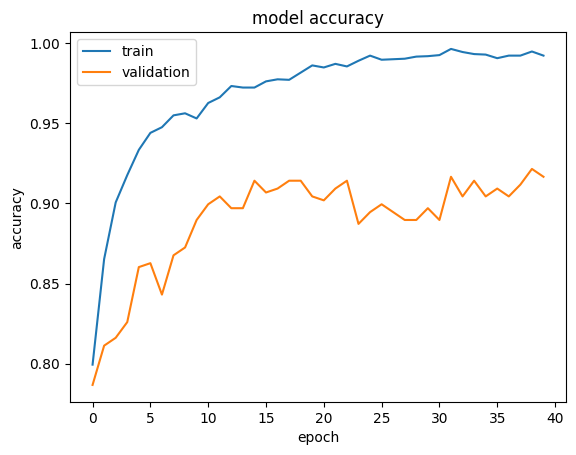

In [39]:
plot_hist(history_fine_tuning)

The model seems consistent, let's save it.

In [40]:
# Save the entire model
model.save("../models/consistent_image_misalignment_full_model_enb3.keras")

## 04- Inference on Test dataset and Metrics

In [41]:
y_pred_proba = model.predict(test_ds)
y_pred = (y_pred_proba > 0.5).astype(int) 

63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

E0424 16:31:23.169557   89764 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0424 16:31:24.922321   89784 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0424 16:31:25.670489   89769 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0424 16:31:26.540146   89775 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0424 16:31:26.828953   89787 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0424 16:31:27.258555   89784 cuda_timer.cc:8

64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step


In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       421
           1       0.90      0.91      0.90       598

    accuracy                           0.88      1019
   macro avg       0.88      0.88      0.88      1019
weighted avg       0.88      0.88      0.88      1019



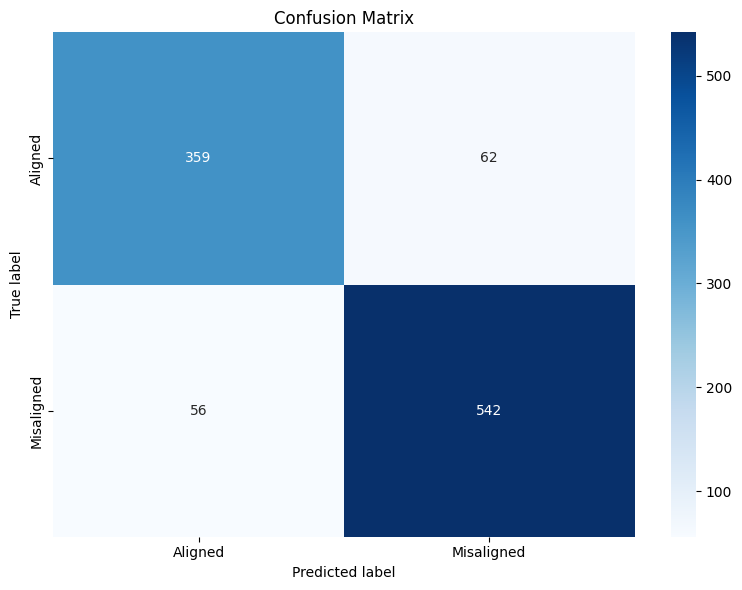

In [43]:
def plot_confusion_matrix(y_true, y_pred, class_names=None):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

# Binary example
plot_confusion_matrix(y_test, y_pred, class_names=["Aligned", "Misaligned"])

## 05- Image Embeddings validation

In [44]:
# Create embedding model (everything up to the final Dense layer)
embedding_model = keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output  # layer just before the output
)

In [60]:
# Extract embeddings
test_dataset = ImageDataPipeline(X_test, y_test, batch_size=32, shuffle=False)
embeddings = embedding_model.predict(test_dataset)

# Reduce to 3 dimensions
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings)
print(f"KL divergence: {tsne.kl_divergence_:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
KL divergence: 0.4635


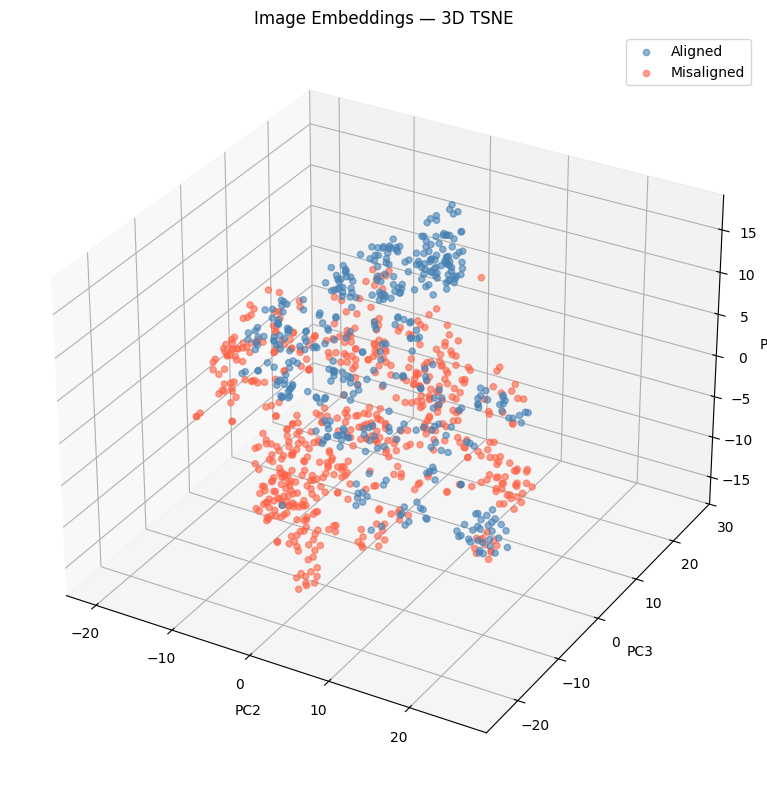

In [62]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection="3d")

# Assuming binary labels (0 and 1)
colors = ["steelblue", "tomato"]
class_names = ["Aligned", "Misaligned"]

for class_idx, (color, name) in enumerate(zip(colors, class_names)):
    mask = np.array(y_test) == class_idx
    ax.scatter(
        embeddings_3d[mask, 1],
        embeddings_3d[mask, 2],
        embeddings_3d[mask, 0],
        c=color,
        label=name,
        alpha=0.6,
        s=20,
    )

ax.set_xlabel(f"PC2")
ax.set_ylabel(f"PC3")
ax.set_zlabel(f"PC1")
ax.set_title("Image Embeddings — 3D TSNE")
ax.legend()
plt.tight_layout()
plt.show()